![폐암 수술 환자 생존율 예측](data/폐암수술환자생존율예측.JPG)

폐암 수술 환자의 생존율 예측 데이타셋 살펴보기
폐암 환자 수술 기록 데이터
총 470개 관측치, 17개 속성으로 구성
설명변수(X) – 16개, 종속변수(클래스, 레이블, Y) – 1개(1:생존, 0:사망)

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

In [ ]:
tf.random.set_seed(0) # 시드 고정

In [2]:
import pandas as pd

In [3]:
# 파일 경로를 지정하여 읽어옵니다.
# 파일명에 공백이 있다면 문자열 안에 그대로 적어주면 됩니다.
df = pd.read_csv('data/surgery1.csv', header=None)

# 데이터의 상위 5행을 출력하여 확인합니다.
print(df.head())

   0     1     2   3   4   5   6   7   8   9   10  11  12  13  14  15  16
0   1  2.88  2.16   1   0   0   0   1   1   3   0   0   0   1   0  60   0
1   2  3.40  1.88   0   0   0   0   0   0   1   0   0   0   1   0  51   0
2   2  2.76  2.08   1   0   0   0   1   0   0   0   0   0   1   0  59   0
3   2  3.68  3.04   0   0   0   0   0   0   0   0   0   0   0   0  54   0
4   2  2.44  0.96   2   0   1   0   1   1   0   0   0   0   1   0  73   1


In [ ]:
x = df.iloc[:, 0:16] # 0~15번째 열이 특징입니다.
y = df.iloc[:, 16] # 16번째 열이 레이블입니다.

In [10]:
df.rename(columns={16: 'label'}, inplace=True) # 16번째 열의 이름을 'label'로 변경합니다.

In [12]:
df['label'].value_counts() # 레이블의 분포를 확인합니다.

label
0    400
1     70
Name: count, dtype: int64

In [17]:
import matplotlib.pyplot as plt
df['label'].value_counts()

label
0    400
1     70
Name: count, dtype: int64

<Axes: xlabel='label'>

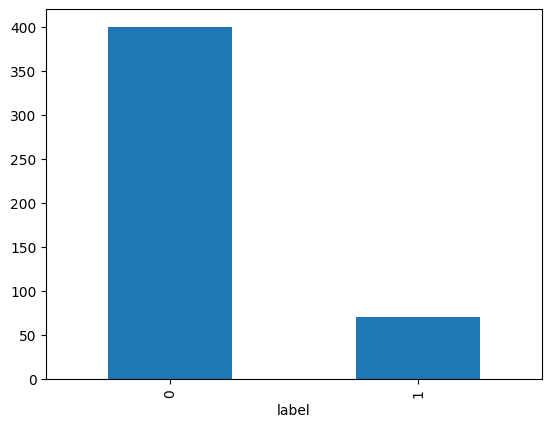

In [ ]:
df['label'].value_counts().plot(kind='bar') # 레이블의 분포를 막대 그래프로 시각화합니다.

딥러닝 모델 정의
1) 입력층 : 입력변수가 16개, input_dim = 16 또는 input_shape = (16, )로 설정
2) 은닉층 : 30개의 노드, 활성화 함수는 relu로 설정
3) 출력층 
출력 값이 1개, Dense의 노드 수를 1으로 설정
출력층의 활성화 함수 : 이항 분류이므로 활성화함수를 sigmoid로 사용

In [18]:
# 1. 모델 선언
model = Sequential()

# 2. 입력층 + 은닉층
# 입력 변수 16개, 은닉층 노드 30개, 활성화 함수 relu
model.add(Dense(30, input_dim=16, activation='relu'))

# 3. 출력층
# 출력 값 1개, 이항 분류를 위한 sigmoid 활성화 함수 사용
model.add(Dense(1, activation='sigmoid'))

c:\hak\kdev\03python\02code\01test\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541 (2.11 KB)

 Trainable params: 541 (2.11 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# loss='binary_crossentropy' (손실 함수)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [42]:
# batch_size : 모델이 한 번에 처리하는 데이터 샘플의 수입니다. 예를 들어, batch_size=10이면 모델이 한 번에 10개의 샘플을 처리하고 가중치를 업데이트합니다. 작은 배치 크기는 더 자주 가중치를 업데이트하지만, 계산 비용이 높아질 수 있습니다. 큰 배치 크기는 계산 비용을 줄일 수 있지만, 가중치 업데이트가 덜 자주 일어나므로 학습이 느려질 수 있습니다.
history = model.fit(x, y, epochs=100, batch_size=16)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8511 - loss: 0.3913 
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3996  
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3930 
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3906 
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3899 
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3896 
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3898 
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3881 
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3887 
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8511 - loss: 0.3884
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3862 
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

In [43]:
model.evaluate(x, y)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8553 - loss: 0.3647  


[0.3647317886352539, 0.8553191423416138]

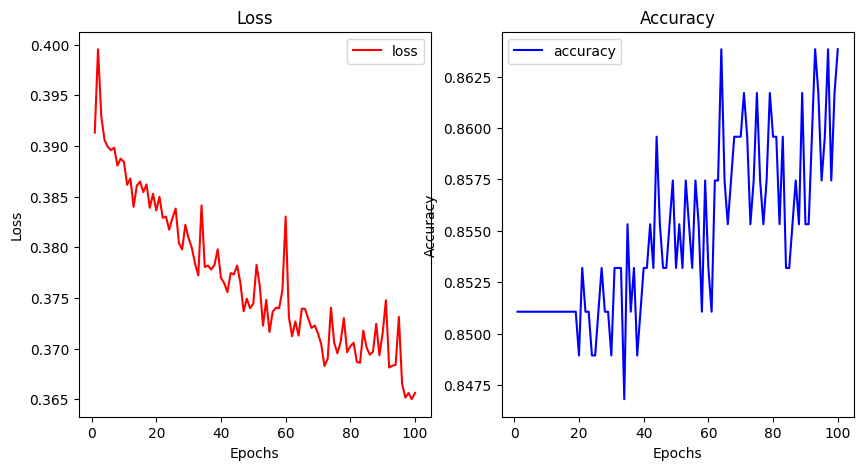

In [45]:
his_dict = history.history
loss = his_dict['loss']
acc = his_dict['accuracy']
epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color="red", label='loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color="blue", label='accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

In [47]:
x[0:1]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1,2.88,2.16,1,0,0,0,1,1,3,0,0,0,1,0,60


In [56]:
y[0:1]

0    0
Name: 16, dtype: int64

In [57]:
model.predict(x[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[0.36149046]], dtype=float32)